# 📚 Uygulamalı Makine Öğrenmesi
## Hafta 3 — Karar Ağaçları & Naive Bayes

---

> **Ders Notu Bilgileri**  
> - **Düzey:** Lisans 3-4. Sınıf & Yüksek Lisans  
> - **Süre:** ~3 ders saati  
> - **Önkoşul:** KNN, Lojistik Regresyon bilgisi  
> - **Kütüphaneler:** NumPy · Pandas · Scikit-learn · Plotly · Seaborn · Altair · graphviz  

---

## 📋 İçindekiler

| # | Konu | Tür |
|---|------|-----|
| 1 | Kütüphane Kurulumu | Kod |
| 2 | Karar Ağacı Nedir? | Teori |
| 3 | Saflık Ölçütleri: Gini & Entropy | Teori + Kod |
| 4 | Bilgi Kazancı (Information Gain) | Teori + Kod |
| 5 | CART Algoritması | Teori |
| 6 | Veri Setleri | Bilgi |
| 7 | EDA: Iris + Wine | Kod |
| 8 | Karar Ağacı — Sıfırdan (NumPy) | Kod |
| 9 | Scikit-learn ile Karar Ağacı | Kod |
| 10 | Ağaç Görselleştirmesi | Kod |
| 11 | Derinlik & Overfitting Analizi | Kod |
| 12 | Özellik Önemleri | Kod |
| 13 | Karar Sınırları Görselleştirmesi | Kod |
| 14 | Naive Bayes Nedir? | Teori |
| 15 | Bayes Teoremi | Teori + Kod |
| 16 | Gaussian Naive Bayes | Kod |
| 17 | Multinomial Naive Bayes (Metin) | Kod |
| 18 | Model Değerlendirme & Karşılaştırma | Kod |
| 19 | Özet & Sonraki Adımlar | Özet |

---
## 1. 📦 Kütüphane Kurulumu & İçe Aktarma

In [1]:
# ─── Temel Kütüphaneler ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Görselleştirme ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import altair as alt

# ─── Ağaç Görselleştirme ────────────────────────────────────────────────────
from sklearn.tree import export_text, plot_tree, export_graphviz

# ─── Scikit-learn: Veri Setleri ─────────────────────────────────────────────
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, fetch_20newsgroups

# ─── Scikit-learn: Ön İşleme ────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ─── Scikit-learn: Modeller ─────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# ─── Scikit-learn: Metrikler ────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, f1_score
)

# ─── Diğer ──────────────────────────────────────────────────────────────────
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ─── Görsel Ayarlar ─────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='husl', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ Tüm kütüphaneler yüklendi!')

✅ Tüm kütüphaneler yüklendi!


---
## 2. 🌳 Karar Ağacı Nedir?

### Tanım
Karar ağacı, bir veri setini ardışık ikili (ya da çoklu) sorular sorarak **kural bazlı** biçimde sınıflara ya da değerlere ayıran bir denetimli öğrenme algoritmasıdır. Yapısı gerçek bir ağacı andırır:

```
           [Kök Düğüm]
          /            \
      [İç Düğüm]    [İç Düğüm]
       /      \          |
   [Yaprak] [Yaprak]  [Yaprak]
```

| Bileşen | Açıklama |
|---------|----------|
| **Kök Düğüm** | Tüm veriyi içeren başlangıç noktası |
| **İç Düğüm** | Bir özellik üzerinde yapılan test/soru |
| **Dal (Branch)** | Test sonucuna göre oluşan yol |
| **Yaprak Düğüm** | Son tahmin — sınıf etiketi ya da değer |

### Temel Özellikler

| Özellik | Açıklama |
|---------|----------|
| **Yorumlanabilirlik** | Çok yüksek — insan tarafından okunabilir kurallar |
| **Ölçeklendirme** | **Gerekmez** — ağaç sıralama tabanlı |
| **Veri türü** | Sayısal + Kategorik — her ikisi de desteklenir |
| **Overfitting riski** | **Yüksek** — derinlik sınırlandırılmazsa |
| **Eksik veri** | Bazı implementasyonlar tolere eder |

### Nasıl Çalışır? — Temel Fikir

Her adımda şu soruyu sor: **"Hangi özellik ve hangi eşik değeri, veriyi en saf (homogen) alt gruplara ayırır?"**  
Bu soruyu yanıtlamak için **saflık ölçütleri** kullanılır: Gini İmpurity ve Entropy.

---
## 3. 📐 Saflık Ölçütleri: Gini İmpurity & Entropy

### Gini İmpurity
Bir düğümdeki veri noktalarının **ne kadar karışık** olduğunu ölçer:

$$\text{Gini}(t) = 1 - \sum_{k=1}^{K} p_k^2$$

- Tüm örnekler aynı sınıftaysa → $\text{Gini} = 0$ (saf düğüm)
- Eşit dağılım (2 sınıf) → $\text{Gini} = 0.5$ (maksimum kirlilik)

### Entropy (Shannon Entropisi)

$$H(t) = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

- Tüm örnekler aynı sınıftaysa → $H = 0$
- Eşit dağılım (2 sınıf) → $H = 1.0$ bit

### Hangi Ölçüt Kullanılmalı?

| | Gini | Entropy |
|--|------|--------|
| **Hesap hızı** | Daha hızlı (log yok) | Biraz daha yavaş |
| **Sonuç farkı** | Genellikle çok küçük | Benzer ağaçlar |
| **sklearn default** | ✅ `criterion='gini'` | `criterion='entropy'` |
| **Tercih** | Hız öncelikli | Bilgi teorisi tutarlılığı |

In [2]:
# ─── Gini ve Entropy Hesabı — Manuel ─────────────────────────────────────────
# Farklı sınıf dağılımları için saflık değerlerini hesaplar

# Örnekler: farklı p değerleri için Gini ve Entropy
p1_values = np.linspace(0.001, 0.999, 300)   # p1: sınıf 1'in oranı
p2_values = 1 - p1_values                     # p2: sınıf 2'nin oranı

# Gini: 1 - Σ pₖ²
gini_vals = 1 - (p1_values**2 + p2_values**2)

# Entropy: -Σ pₖ log₂(pₖ)
eps = 1e-15
entropy_vals = -(p1_values * np.log2(p1_values + eps) +
                 p2_values * np.log2(p2_values + eps))

# Görselleştir
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=p1_values, y=gini_vals,
    mode='lines', line=dict(color='#E74C3C', width=3),
    name='Gini İmpurity'
))

fig.add_trace(go.Scatter(
    x=p1_values, y=entropy_vals / 2,   # /2 ile normalize et (0-1 aralığı)
    mode='lines', line=dict(color='#3498DB', width=3),
    name='Entropy / 2  (normalize)'
))

# Maksimum noktaları işaretle
fig.add_vline(x=0.5, line_dash='dot', line_color='gray',
              annotation_text='p=0.5 → Maksimum kirlilik')

fig.update_layout(
    title='Gini İmpurity vs Entropy — 2 Sınıflı Durum',
    xaxis_title='p₁ (Sınıf 1 oranı)',
    yaxis_title='Saflık Ölçütü Değeri',
    height=420, template='plotly_white'
)
fig.show()

# Örnek hesaplamalar
print('Örnek Hesaplamalar:')
for p1 in [0.0, 0.25, 0.5, 0.75, 1.0]:
    p2 = 1 - p1
    gini = 1 - (p1**2 + p2**2)
    ent  = -(p1*np.log2(p1+eps) + p2*np.log2(p2+eps))
    print(f'  p1={p1:.2f}, p2={p2:.2f} → Gini={gini:.4f}  Entropy={ent:.4f}')

Örnek Hesaplamalar:
  p1=0.00, p2=1.00 → Gini=0.0000  Entropy=-0.0000
  p1=0.25, p2=0.75 → Gini=0.3750  Entropy=0.8113
  p1=0.50, p2=0.50 → Gini=0.5000  Entropy=1.0000
  p1=0.75, p2=0.25 → Gini=0.3750  Entropy=0.8113
  p1=1.00, p2=0.00 → Gini=0.0000  Entropy=-0.0000


---
## 4. 📊 Bilgi Kazancı (Information Gain)

Karar ağacı hangi özelliği ve hangi eşiği seçer? **Bilgi Kazancı** bunu belirler:

$$\text{IG}(t, a) = H(t) - \sum_{v \in \text{values}(a)} \frac{|t_v|}{|t|} H(t_v)$$

Burada:
- $H(t)$: Bölünmeden önce ebeveyn düğümün entropisi
- $H(t_v)$: Bölündükten sonra alt düğümün entropisi
- $|t_v|/|t|$: Alt düğümün ağırlığı (örneklerin oranı)

**CART algoritması** (sklearn'in kullandığı) ağırlıklı Gini azalmasını maksimize eder:

$$\text{Gini Azalma} = \text{Gini}(t) - \frac{N_{sol}}{N} \text{Gini}(t_{sol}) - \frac{N_{sağ}}{N} \text{Gini}(t_{sağ})$$

In [3]:
# ─── Bilgi Kazancı Hesabı — Somut Örnek ─────────────────────────────────────
# Ebeveyn: [5 Pozitif, 5 Negatif] → 10 örnek
# Bölünme A: Sol [4P, 1N] | Sağ [1P, 4N]
# Bölünme B: Sol [3P, 3N] | Sağ [2P, 2N]  (kötü bölünme)

def entropy(p_pos, p_neg):
    """İkili entropy hesabı."""
    total = p_pos + p_neg
    if total == 0:
        return 0
    p1 = p_pos / total
    p2 = p_neg / total
    eps = 1e-15
    return -(p1 * np.log2(p1 + eps) + p2 * np.log2(p2 + eps))

def gini(p_pos, p_neg):
    """İkili Gini impurity hesabı."""
    total = p_pos + p_neg
    if total == 0:
        return 0
    p1 = p_pos / total
    p2 = p_neg / total
    return 1 - (p1**2 + p2**2)

# Ebeveyn
parent = (5, 5)  # 5 pozitif, 5 negatif
H_parent = entropy(*parent)
G_parent = gini(*parent)
print(f'Ebeveyn [5P, 5N]:  Entropy={H_parent:.4f}  Gini={G_parent:.4f}')
print()

# Bölünme A: daha iyi
left_A, right_A = (4, 1), (1, 4)
N_total = parent[0] + parent[1]

H_left_A  = entropy(*left_A)
H_right_A = entropy(*right_A)
IG_A = H_parent - (sum(left_A)/N_total)*H_left_A - (sum(right_A)/N_total)*H_right_A

G_left_A  = gini(*left_A)
G_right_A = gini(*right_A)
GG_A = G_parent - (sum(left_A)/N_total)*G_left_A - (sum(right_A)/N_total)*G_right_A

print(f'Bölünme A — Sol [4P,1N] | Sağ [1P,4N]')
print(f'  Entropy IG = {IG_A:.4f}  ← Bilgi Kazancı')
print(f'  Gini Azalma= {GG_A:.4f}')
print()

# Bölünme B: kötü
left_B, right_B = (3, 3), (2, 2)

H_left_B  = entropy(*left_B)
H_right_B = entropy(*right_B)
IG_B = H_parent - (sum(left_B)/N_total)*H_left_B - (sum(right_B)/N_total)*H_right_B

print(f'Bölünme B — Sol [3P,3N] | Sağ [2P,2N]  ← kötü bölünme')
print(f'  Entropy IG = {IG_B:.4f}  ← Bilgi Kazancı sıfır!')
print()
print('✅ Bölünme A seçilir çünkü IG_A >> IG_B')

Ebeveyn [5P, 5N]:  Entropy=1.0000  Gini=0.5000

Bölünme A — Sol [4P,1N] | Sağ [1P,4N]
  Entropy IG = 0.2781  ← Bilgi Kazancı
  Gini Azalma= 0.1800

Bölünme B — Sol [3P,3N] | Sağ [2P,2N]  ← kötü bölünme
  Entropy IG = 0.0000  ← Bilgi Kazancı sıfır!

✅ Bölünme A seçilir çünkü IG_A >> IG_B


---
## 5. ⚙️ CART Algoritması

**CART (Classification and Regression Trees)**, sklearn'in kullandığı algoritma.

### Algoritma Adımları:

```
GİRDİ: Eğitim seti D, Kriter (gini/entropy), max_depth, min_samples_split

ADIM 1: Tüm özellikler j ve eşikler t için → Gini azalmasını hesapla
        (j*, t*) = argmax Gini_decrease(D, j, t)

ADIM 2: Veriyi (j*, t*) ile D_sol ve D_sağ'a böl

ADIM 3: Her alt küme için özyinelemeli olarak tekrar et

ADIM 4: Dur koşulları:
        - Düğüm saf (tek sınıf)
        - max_depth'e ulaşıldı
        - min_samples_split'ten az örnek
        - Bölme kazancı sıfır
```

### Önemli Hiperparametreler:

| Parametre | Varsayılan | Açıklama |
|-----------|-----------|----------|
| `max_depth` | None | Maksimum derinlik. None → tam büyüme (overfitting!) |
| `min_samples_split` | 2 | Bölme için minimum örnek sayısı |
| `min_samples_leaf` | 1 | Yaprakta minimum örnek sayısı |
| `max_features` | None | Her bölme için kullanılan maksimum özellik |
| `criterion` | `'gini'` | `'gini'` veya `'entropy'` |
| `ccp_alpha` | 0 | Budama parametresi (cost-complexity pruning) |

---
## 6. 🗃️ Kullanılan Veri Setleri

### 📌 Iris (Karar Ağacı Görselleştirme)
| Bilgi | Detay |
|-------|-------|
| **Kaynak** | R.A. Fisher (1936), UCI ML Repository |
| **Scikit-learn** | `sklearn.datasets.load_iris()` |
| **Boyut** | 150 × 4 özellik, 3 sınıf |
| **Amaç** | Küçük, yorumlanabilir ağaç |

### 📌 Wine Quality (Çok Sınıflı Karşılaştırma)
| Bilgi | Detay |
|-------|-------|
| **Kaynak** | Forina et al. (1986), UCI ML Repository |
| **Scikit-learn** | `sklearn.datasets.load_wine()` |
| **Boyut** | 178 × 13 özellik, 3 sınıf |
| **Amaç** | Özellik önemi analizi |

### 📌 20 Newsgroups (Naive Bayes — Metin Sınıflandırma)
| Bilgi | Detay |
|-------|-------|
| **Kaynak** | Lang (1995), MIT/Usenet haber grupları |
| **Scikit-learn** | `sklearn.datasets.fetch_20newsgroups()` |
| **Boyut** | ~18.000 belge, 20 kategori |
| **Amaç** | Multinomial Naive Bayes metin sınıflandırma |

In [4]:
# ─── Veri Setlerini Yükle ────────────────────────────────────────────────────

# Iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['species'] = [iris.target_names[t] for t in iris.target]

# Wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine['class'] = [wine.target_names[t] for t in wine.target]

print('=== VERİ SETİ ÖZETİ ===')
print(f'Iris  : {X_iris.shape}  →  {Counter(y_iris)}')
print(f'Wine  : {X_wine.shape}  →  {Counter(y_wine)}')
print()
df_iris.head(3)

=== VERİ SETİ ÖZETİ ===
Iris  : (150, 4)  →  Counter({np.int64(0): 50, np.int64(1): 50, np.int64(2): 50})
Wine  : (178, 13)  →  Counter({np.int64(1): 71, np.int64(0): 59, np.int64(2): 48})



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa


---
## 7. 🔍 EDA

In [5]:
# ─── Iris EDA: Karar Ağacının Neye Göre Bölündüğünü Anlama ───────────────────
# Petal özellikleri sınıfları çok daha iyi ayırıyor

fig = px.scatter_matrix(
    df_iris,
    dimensions=['sepal length (cm)','sepal width (cm)',
                'petal length (cm)','petal width (cm)'],
    color='species',
    title='Iris — Özellik Çifti Dağılım Matrisi',
    color_discrete_map={'setosa':'#1f77b4','versicolor':'#ff7f0e','virginica':'#2ca02c'},
    opacity=0.75
)
fig.update_traces(diagonal_visible=False, showupperhalf=False)
fig.update_layout(height=520)
fig.show()
print('💡 Petal özellikleri sınıfları daha net ayırıyor → ağaç bunları tercih edecek!')

💡 Petal özellikleri sınıfları daha net ayırıyor → ağaç bunları tercih edecek!


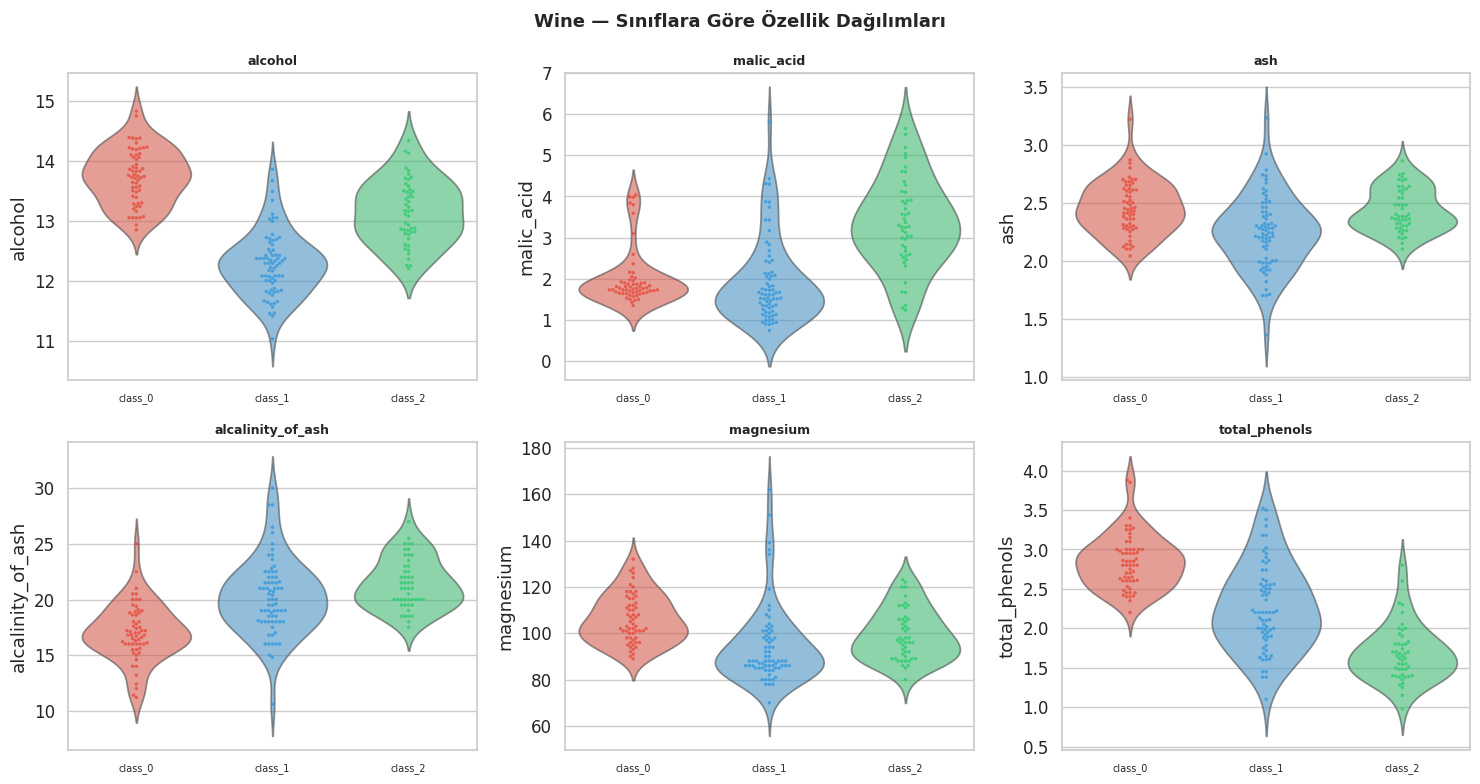

💡 Alcohol ve Proline, sınıflar arasında en güçlü ayrımı sağlıyor.


In [6]:
# ─── Wine EDA: Özellik Dağılımları + Korelasyon (Seaborn + Altair) ───────────

# Seaborn: İlk 6 özellik için boxplot
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
fig.suptitle('Wine — Sınıflara Göre Özellik Dağılımları', fontsize=13, fontweight='bold')

palette3 = ['#E74C3C', '#3498DB', '#2ECC71']
key_feats = wine.feature_names[:6]

for i, feat in enumerate(key_feats):
    # Violin + Swarm
    sns.violinplot(data=df_wine, x='class', y=feat,
                   palette=palette3, ax=axes[i], inner=None, alpha=0.6)
    sns.swarmplot(data=df_wine, x='class', y=feat,
                  palette=palette3, ax=axes[i], size=2.5, alpha=0.8)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.show()
print('💡 Alcohol ve Proline, sınıflar arasında en güçlü ayrımı sağlıyor.')

---
## 8. 🛠️ Karar Ağacı — Sıfırdan (NumPy ile)

Algoritmanın her adımını anlamak için basit bir CART implementasyonu yazıyoruz.

In [7]:
# ─── Düğüm Yapısı ─────────────────────────────────────────────────────────────
# Her düğüm: bölünme bilgisi veya yaprak tahmini içerir

class Node:
    def __init__(self, feature=None, threshold=None, left=None,
                 right=None, value=None):
        self.feature   = feature     # Bölme özelliği indeksi
        self.threshold = threshold   # Bölme eşiği
        self.left      = left        # Sol alt ağaç
        self.right     = right       # Sağ alt ağaç
        self.value     = value       # Yaprak: tahmin değeri (sınıf)

    @property
    def is_leaf(self):
        return self.value is not None

print('✅ Node sınıfı tanımlandı')

✅ Node sınıfı tanımlandı


In [8]:
# ─── Gini İmpurity Fonksiyonu ────────────────────────────────────────────────

def gini_impurity(y):
    """
    y dizisindeki sınıfların Gini impurity değerini hesapla.
    Gini(t) = 1 - Σ pₖ²
    """
    n = len(y)
    if n == 0:
        return 0
    # Her sınıfın oranını hesapla
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / n
    return 1 - np.sum(probs ** 2)

# Test
y_pure  = np.array([0, 0, 0, 0, 0])  # Saf düğüm
y_mixed = np.array([0, 0, 1, 1, 1])  # Karışık düğüm
y_equal = np.array([0, 1, 0, 1])     # Eşit dağılım

print(f'Saf düğüm  [0,0,0,0,0]  → Gini = {gini_impurity(y_pure):.4f}')
print(f'Karışık    [0,0,1,1,1]  → Gini = {gini_impurity(y_mixed):.4f}')
print(f'Eşit [0,1,0,1]          → Gini = {gini_impurity(y_equal):.4f}  (max=0.5)')

Saf düğüm  [0,0,0,0,0]  → Gini = 0.0000
Karışık    [0,0,1,1,1]  → Gini = 0.4800
Eşit [0,1,0,1]          → Gini = 0.5000  (max=0.5)


In [9]:
# ─── En İyi Bölme Noktasını Bulma ────────────────────────────────────────────

def best_split(X, y):
    """
    Tüm özellikler ve eşikler arasında Gini azalmasını maksimize eden
    (özellik, eşik) çiftini bul.
    """
    n_samples, n_features = X.shape
    best_gini_decrease = -1
    best_feat, best_thresh = None, None

    parent_gini = gini_impurity(y)   # Ebeveyn düğümün saflığı

    for feat_idx in range(n_features):
        # Bu özelliğin tüm benzersiz değerleri → olası eşikler
        thresholds = np.unique(X[:, feat_idx])

        for thresh in thresholds:
            # İkiye böl
            left_mask  = X[:, feat_idx] <= thresh
            right_mask = ~left_mask

            n_left  = left_mask.sum()
            n_right = right_mask.sum()

            if n_left == 0 or n_right == 0:
                continue  # Boş alt küme → atla

            # Ağırlıklı Gini
            gini_left  = gini_impurity(y[left_mask])
            gini_right = gini_impurity(y[right_mask])
            weighted_gini = (n_left/n_samples)*gini_left + (n_right/n_samples)*gini_right

            # Gini azalması
            gini_decrease = parent_gini - weighted_gini

            if gini_decrease > best_gini_decrease:
                best_gini_decrease = gini_decrease
                best_feat   = feat_idx
                best_thresh = thresh

    return best_feat, best_thresh, best_gini_decrease

# Iris verisinde test
X_small = iris.data[:, 2:]   # petal_length, petal_width
y_small = iris.target

feat, thresh, decrease = best_split(X_small, y_small)
feat_names = ['petal length', 'petal width']
print(f'En iyi bölme: {feat_names[feat]} <= {thresh:.2f}')
print(f'Gini azalması: {decrease:.4f}')

En iyi bölme: petal length <= 1.90
Gini azalması: 0.3333


In [10]:
# ─── Ağaç İnşası — Özyinelemeli ──────────────────────────────────────────────

def build_tree(X, y, depth=0, max_depth=3, min_samples_split=2):
    """
    Özyinelemeli CART ağaç inşaatı.
    Dur koşulları: saf düğüm, max_depth, az örnek.
    """
    n_samples = len(y)
    n_classes = len(np.unique(y))

    # ── Dur koşulları ──────────────────────────────────────────────────────
    # 1) Tek sınıf kaldı (saf düğüm)
    if n_classes == 1:
        return Node(value=y[0])

    # 2) Maksimum derinliğe ulaşıldı
    if depth >= max_depth:
        # Çoğunluk sınıfını tahmin et
        majority_class = Counter(y).most_common(1)[0][0]
        return Node(value=majority_class)

    # 3) Minimum örnek sayısı yeterli değil
    if n_samples < min_samples_split:
        majority_class = Counter(y).most_common(1)[0][0]
        return Node(value=majority_class)

    # ── En iyi bölmeyi bul ──────────────────────────────────────────────────
    feat, thresh, decrease = best_split(X, y)

    if feat is None or decrease <= 0:
        majority_class = Counter(y).most_common(1)[0][0]
        return Node(value=majority_class)

    # ── Böl ve özyinelemeli inşa ────────────────────────────────────────────
    left_mask  = X[:, feat] <= thresh
    right_mask = ~left_mask

    left_child  = build_tree(X[left_mask],  y[left_mask],
                              depth+1, max_depth, min_samples_split)
    right_child = build_tree(X[right_mask], y[right_mask],
                              depth+1, max_depth, min_samples_split)

    return Node(feature=feat, threshold=thresh,
                left=left_child, right=right_child)

print('✅ build_tree fonksiyonu tanımlandı')

✅ build_tree fonksiyonu tanımlandı


In [11]:
# ─── Tahmin Fonksiyonu ────────────────────────────────────────────────────────

def predict_one(node, x):
    """Tek bir örnek için ağaçta yol kat ederek tahmin yap."""
    if node.is_leaf:
        return node.value
    # Bölme koşulunu kontrol et
    if x[node.feature] <= node.threshold:
        return predict_one(node.left, x)
    else:
        return predict_one(node.right, x)

def predict_tree(node, X):
    """Tüm örnekler için tahmin."""
    return np.array([predict_one(node, x) for x in X])

# ─── Modeli Eğit ve Test Et ───────────────────────────────────────────────────
# Iris verisi — petal özellikleri
X_tr, X_te, y_tr, y_te = train_test_split(
    iris.data[:, 2:], iris.target,
    test_size=0.25, random_state=RANDOM_STATE, stratify=iris.target
)

# max_depth=3 ile ağaç inşa et
tree_root = build_tree(X_tr, y_tr, max_depth=3)

# Tahmin
y_pred_scratch = predict_tree(tree_root, X_te)
acc_scratch    = accuracy_score(y_te, y_pred_scratch)

print(f'Sıfırdan Karar Ağacı (max_depth=3):')
print(f'  Test Doğruluğu: {acc_scratch:.4f} ({acc_scratch*100:.1f}%)')

Sıfırdan Karar Ağacı (max_depth=3):
  Test Doğruluğu: 0.9211 (92.1%)


---
## 9. 🔬 Scikit-learn ile Karar Ağacı

In [12]:
# ─── Train-Test Split ─────────────────────────────────────────────────────────
# Tüm Iris özellikleri
X_ir_tr, X_ir_te, y_ir_tr, y_ir_te = train_test_split(
    X_iris, y_iris,
    test_size=0.25, random_state=RANDOM_STATE, stratify=y_iris
)

print(f'Eğitim: {X_ir_tr.shape[0]} örnek')
print(f'Test  : {X_ir_te.shape[0]} örnek')

Eğitim: 112 örnek
Test  : 38 örnek


In [13]:
# ─── Scikit-learn DecisionTreeClassifier ─────────────────────────────────────
# criterion='gini', max_depth=4 ile başlayalım

dt_model = DecisionTreeClassifier(
    criterion='gini',        # Gini impurity
    max_depth=4,             # Maksimum derinlik
    min_samples_split=5,     # Bölme için minimum örnekler
    min_samples_leaf=2,      # Yaprakta minimum örnek
    random_state=RANDOM_STATE
)

dt_model.fit(X_ir_tr, y_ir_tr)

y_pred_dt = dt_model.predict(X_ir_te)
acc_dt    = accuracy_score(y_ir_te, y_pred_dt)

print(f'=== Scikit-learn DecisionTreeClassifier ===')
print(f'  max_depth  : {dt_model.max_depth}')
print(f'  criterion  : {dt_model.criterion}')
print(f'  n_leaves   : {dt_model.get_n_leaves()}')
print(f'  depth      : {dt_model.get_depth()}')
print(f'  Test Acc   : {acc_dt:.4f} ({acc_dt*100:.1f}%)')

=== Scikit-learn DecisionTreeClassifier ===
  max_depth  : 4
  criterion  : gini
  n_leaves   : 6
  depth      : 4
  Test Acc   : 0.9211 (92.1%)


In [14]:
# ─── Sınıflandırma Raporu ────────────────────────────────────────────────────

print(classification_report(
    y_ir_te, y_pred_dt,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



---
## 10. 🌲 Ağaç Görselleştirmesi

Karar ağacının en güçlü avantajı: **Görsel olarak yorumlanabilir kural yapısı**.

In [15]:
# ─── Metin Formatında Ağaç ───────────────────────────────────────────────────
# Ağaç yapısını kural dizisi olarak göster

tree_text = export_text(
    dt_model,
    feature_names=list(iris.feature_names)
)
print('Karar Ağacı — Metin Kuralları:')
print(tree_text)

Karar Ağacı — Metin Kuralları:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.85
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 1
|   |--- petal length (cm) >  4.85
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- petal length (cm) <= 4.95
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.95
|   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- class: 2



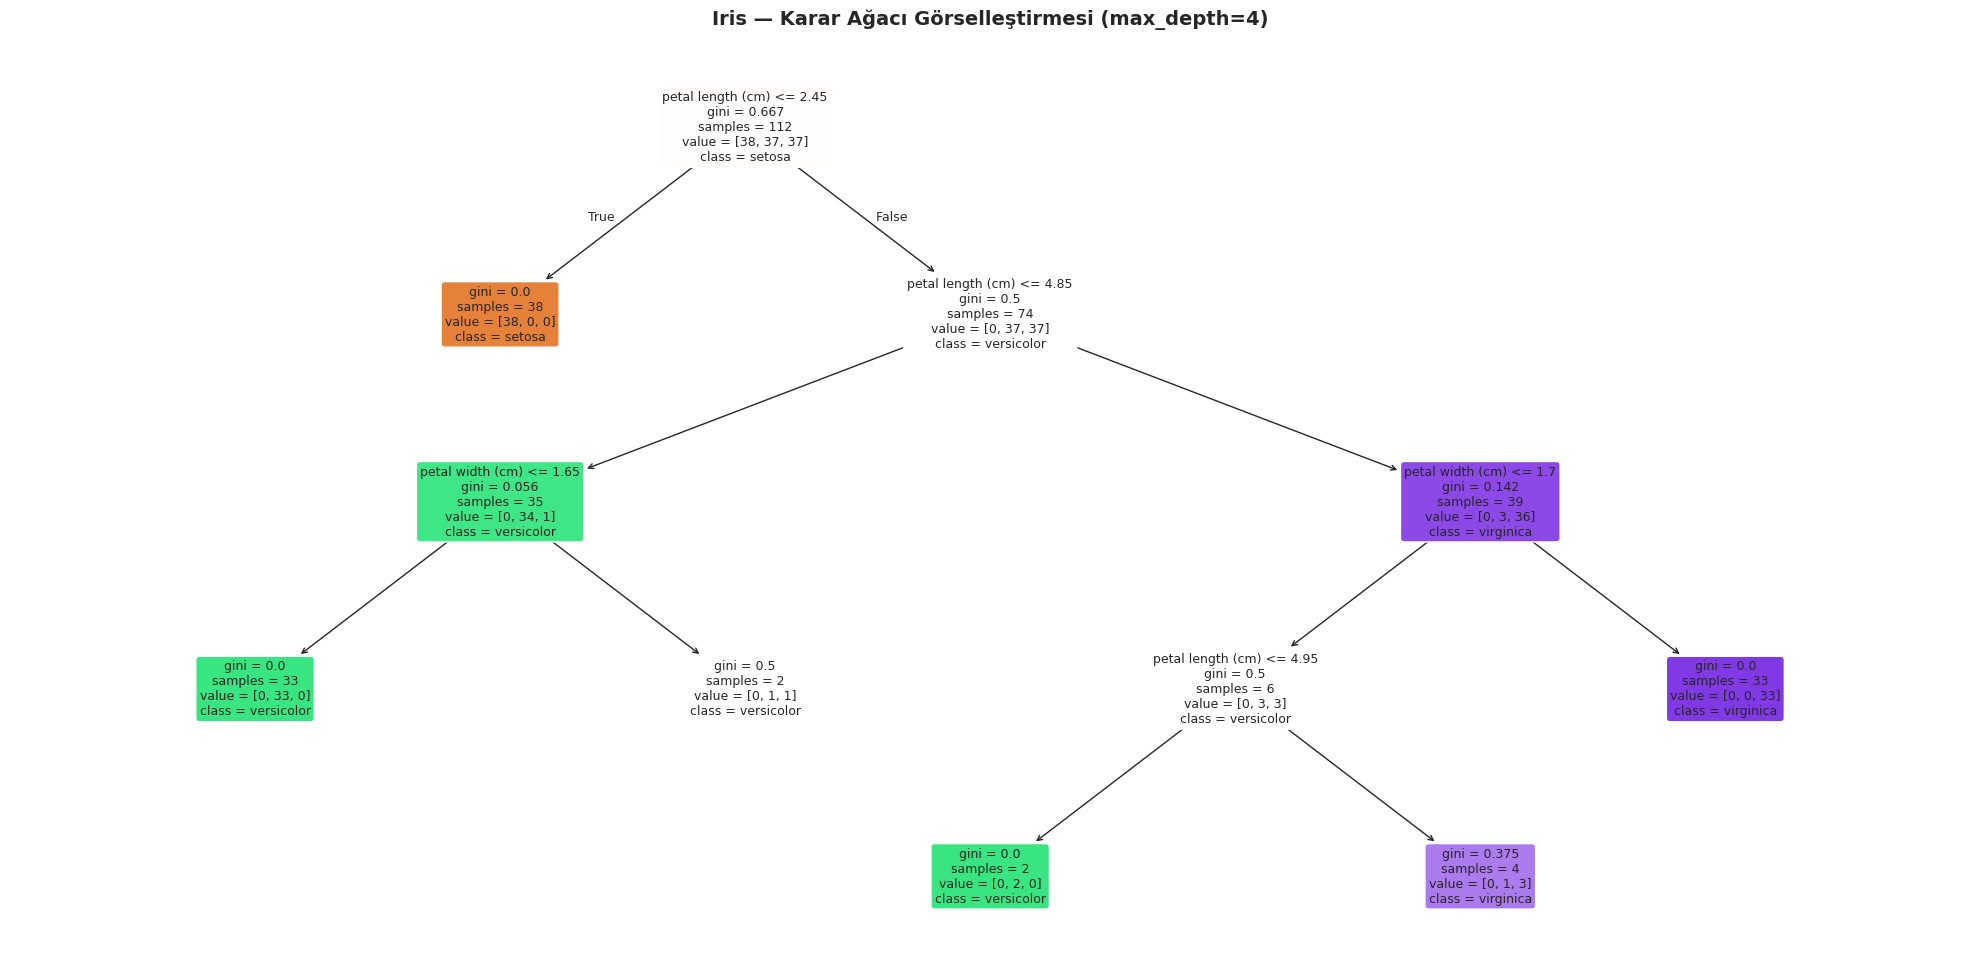

💡 Mavi = Setosa, Turuncu = Versicolor, Yeşil = Virginica
💡 Her kutuda: bölme koşulu, Gini değeri, örnek sayısı, sınıf tahmini


In [16]:
# ─── Matplotlib ile Ağaç Çizimi ──────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,           # Sınıfa göre renk
    rounded=True,          # Yuvarlatılmış kutular
    fontsize=9,
    impurity=True,         # Gini değerini göster
    precision=3,
    ax=ax
)

ax.set_title('Iris — Karar Ağacı Görselleştirmesi (max_depth=4)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree_iris.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Mavi = Setosa, Turuncu = Versicolor, Yeşil = Virginica')
print('💡 Her kutuda: bölme koşulu, Gini değeri, örnek sayısı, sınıf tahmini')

---
## 11. 📉 Derinlik & Overfitting Analizi

**max_depth** karar ağacının en kritik hiperparametresidir:  
- Çok küçük → underfitting (yüksek bias)  
- Çok büyük → overfitting (yüksek variance)  
- `max_depth=None` → tüm veriyi ezber (eğitim acc=%100 ama test düşük)

In [17]:
# ─── Farklı max_depth Değerleri için Performans ───────────────────────────────

depths       = list(range(1, 16))   # 1'den 15'e
train_scores = []
test_scores  = []
cv_scores    = []
n_leaves_list = []

for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth=depth, random_state=RANDOM_STATE
    )
    dt.fit(X_ir_tr, y_ir_tr)

    train_scores.append(dt.score(X_ir_tr, y_ir_tr))
    test_scores.append(dt.score(X_ir_te, y_ir_te))
    n_leaves_list.append(dt.get_n_leaves())

    cv = cross_val_score(dt, X_ir_tr, y_ir_tr, cv=5, scoring='accuracy')
    cv_scores.append(cv.mean())

best_depth = depths[np.argmax(cv_scores)]
print(f'En iyi derinlik (CV): {best_depth}')
print(f'CV Doğruluğu        : {max(cv_scores):.4f}')

En iyi derinlik (CV): 3
CV Doğruluğu        : 0.9375


In [18]:
# ─── Altair ile Derinlik Analizi Grafiği ─────────────────────────────────────

df_depth = pd.DataFrame({
    'Derinlik': depths * 3,
    'Doğruluk': train_scores + test_scores + cv_scores,
    'Küme': (['Eğitim'] * len(depths) +
              ['Test']   * len(depths) +
              ['CV-5']   * len(depths))
})

line = alt.Chart(df_depth).mark_line(point=True).encode(
    x=alt.X('Derinlik:Q', title='max_depth'),
    y=alt.Y('Doğruluk:Q', scale=alt.Scale(domain=[0.7, 1.02]),
             title='Doğruluk'),
    color=alt.Color('Küme:N',
        scale=alt.Scale(
            domain=['Eğitim','Test','CV-5'],
            range=['#E74C3C','#2196F3','#FF9800']
        )
    ),
    tooltip=['Derinlik:Q', alt.Tooltip('Doğruluk:Q', format='.4f'), 'Küme:N']
).properties(
    width=540, height=280,
    title=alt.TitleParams(
        text='Karar Ağacı — Derinlik vs Doğruluk (Overfitting Analizi)',
        fontSize=12
    )
)

best_line = alt.Chart(pd.DataFrame({'d':[best_depth]})).mark_rule(
    color='green', strokeDash=[5,3], strokeWidth=2
).encode(x='d:Q')

(line + best_line).configure_legend(orient='bottom-right').show()

print(f'💡 Kırmızı çizgi (Eğitim) erken %100 olurken Test/CV arkada kalıyor = overfitting!')

alt.LayerChart(...)

💡 Kırmızı çizgi (Eğitim) erken %100 olurken Test/CV arkada kalıyor = overfitting!


---
## 12. 🏆 Özellik Önemleri (Feature Importances)

Karar ağacı her bölme adımında ne kadar Gini azalması sağlandığını kaydeder.  
Bu değerlerin toplamı (normallenmiş) özellik önemini verir:

$$\text{Importance}(j) = \frac{\sum_{t: \text{split on } j} N_t \cdot \Delta\text{Gini}(t)}{\sum_{t'} N_{t'} \cdot \Delta\text{Gini}(t')}$$

In [19]:
# ─── Wine Verisi ile Özellik Önemi Analizi ───────────────────────────────────

# Wine için train-test split
X_wn_tr, X_wn_te, y_wn_tr, y_wn_te = train_test_split(
    X_wine, y_wine,
    test_size=0.25, random_state=RANDOM_STATE, stratify=y_wine
)

# Karar ağacını eğit
dt_wine = DecisionTreeClassifier(
    max_depth=5, criterion='entropy', random_state=RANDOM_STATE
)
dt_wine.fit(X_wn_tr, y_wn_tr)

# Özellik önemlerini DataFrame'e aktar
feat_imp = pd.DataFrame({
    'Özellik'  : wine.feature_names,
    'Önem'     : dt_wine.feature_importances_
}).sort_values('Önem', ascending=True)

# Plotly yatay bar grafiği
fig = go.Figure(go.Bar(
    x=feat_imp['Önem'],
    y=feat_imp['Özellik'],
    orientation='h',
    marker_color=feat_imp['Önem'],
    marker_colorscale='Viridis',
    text=[f'{v:.3f}' for v in feat_imp['Önem']],
    textposition='outside'
))

fig.update_layout(
    title='Wine — Karar Ağacı Özellik Önemleri (Gini Bazlı)',
    xaxis_title='Önem Skoru',
    height=520, template='plotly_white'
)
fig.show()

top3 = feat_imp.nlargest(3, 'Önem')['Özellik'].tolist()
print(f'\nEn önemli 3 özellik: {top3}')
print(f'Wine Test Doğruluğu: {dt_wine.score(X_wn_te, y_wn_te):.4f}')


En önemli 3 özellik: ['flavanoids', 'alcohol', 'hue']
Wine Test Doğruluğu: 0.9111


---
## 13. 🗺️ Karar Sınırları Görselleştirmesi

Karar ağacının karar sınırları her zaman **dikey veya yatay çizgilerden** oluşur —  
çünkü her bölme tek bir özelliğe göre yapılır.

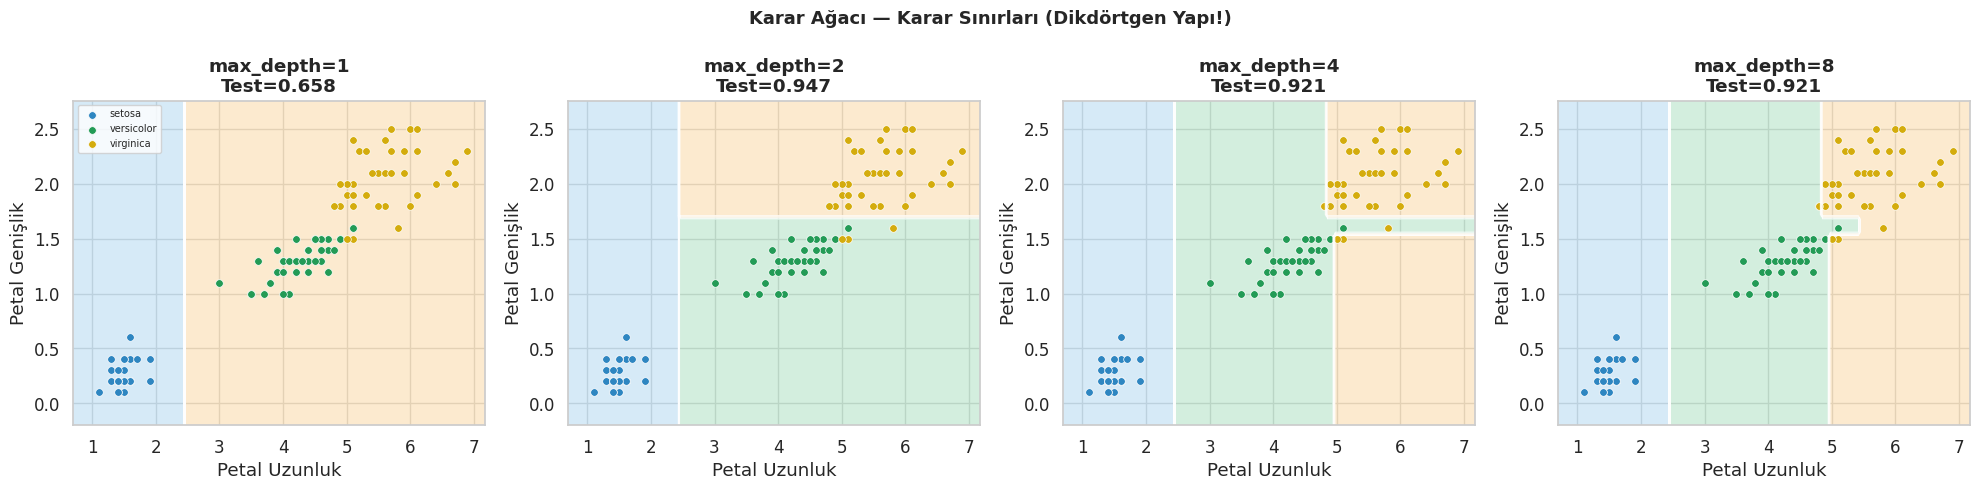

💡 Derin ağaçlarda sınırlar "kırılgan" görünür → overfitting işareti!


In [20]:
# ─── Karar Sınırları — Farklı max_depth Değerleri ───────────────────────────

# 2D görselleştirme için petal özellikleri
X_2d = iris.data[:, 2:]   # petal_length, petal_width

X_2d_tr, X_2d_te, y_2d_tr, y_2d_te = train_test_split(
    X_2d, iris.target,
    test_size=0.25, random_state=RANDOM_STATE, stratify=iris.target
)

depth_list   = [1, 2, 4, 8]
fig, axes    = plt.subplots(1, 4, figsize=(20, 5))
cmap_light   = mcolors.ListedColormap(['#AED6F1', '#A9DFBF', '#FAD7A0'])
color_points = ['#2E86C1', '#239B56', '#D4AC0D']

h = 0.04
x0_min, x0_max = X_2d[:, 0].min()-0.3, X_2d[:, 0].max()+0.3
x1_min, x1_max = X_2d[:, 1].min()-0.3, X_2d[:, 1].max()+0.3
xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                     np.arange(x1_min, x1_max, h))

for ax, depth in zip(axes, depth_list):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    dt.fit(X_2d_tr, y_2d_tr)

    Z = dt.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.5, cmap=cmap_light)
    ax.contour(xx, yy, Z, colors='white', linewidths=0.7)

    for cls, c in enumerate(color_points):
        mask = y_2d_tr == cls
        ax.scatter(X_2d_tr[mask, 0], X_2d_tr[mask, 1],
                   c=c, s=30, edgecolors='white', linewidth=0.5,
                   label=iris.target_names[cls])

    test_acc = dt.score(X_2d_te, y_2d_te)
    ax.set_title(f'max_depth={depth}\nTest={test_acc:.3f}', fontweight='bold')
    ax.set_xlabel('Petal Uzunluk'); ax.set_ylabel('Petal Genişlik')

axes[0].legend(fontsize=7, loc='upper left')
plt.suptitle('Karar Ağacı — Karar Sınırları (Dikdörtgen Yapı!)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 Derin ağaçlarda sınırlar "kırılgan" görünür → overfitting işareti!')

---
## 14. 🔬 Naive Bayes Nedir?

### Tanım
**Naive Bayes**, Bayes teoremini kullanarak sınıf olasılıklarını hesaplayan, özellikler arasında **koşullu bağımsızlık varsayımı** yapan olasılıksal bir sınıflandırıcıdır.

### Neden 'Naive' (Saf/Basit)?

> **Naive Varsayım:** Tüm özellikler birbirinden koşullu olarak bağımsızdır:
$$P(x_1, x_2, \ldots, x_d \mid y) = \prod_{j=1}^{d} P(x_j \mid y)$$

Bu varsayım gerçekte neredeyse hiç doğru olmaz — ama yine de şaşırtıcı derecede iyi çalışır!

### Naive Bayes Türleri:

| Tür | Veri Tipi | Kullanım Alanı |
|-----|-----------|----------------|
| **Gaussian NB** | Sürekli sayısal | Tıbbi tanı, sensör verisi |
| **Multinomial NB** | Tam sayı sayımları | Metin sınıflandırma, TF kelime sayımı |
| **Bernoulli NB** | İkili (0/1) özellikler | Belge içinde kelime var/yok |
| **Complement NB** | Kelime sayımı | Dengesiz metin veri setleri |

---
## 15. ⚖️ Bayes Teoremi

### Temel Formül:

$$P(y \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid y) \cdot P(y)}{P(\mathbf{x})}$$

Burada:
- $P(y)$: **Prior** — etiket bilgisinden önceki sınıf olasılığı (eğitim frekansı)
- $P(\mathbf{x} \mid y)$: **Likelihood** — sınıf bilindiğinde veri olasılığı
- $P(\mathbf{x})$: **Kanıt (Evidence)** — normalizasyon sabiti (sınıfa göre değişmez)
- $P(y \mid \mathbf{x})$: **Posterior** — tahmin etmek istediğimiz olasılık

### Sınıflandırma Kuralı (MAP):

$$\hat{y} = \arg\max_{k} P(y=k) \prod_{j=1}^{d} P(x_j \mid y=k)$$

Sayısal kararlılık için log-uzayında hesaplanır:

$$\hat{y} = \arg\max_{k} \left[ \log P(y=k) + \sum_{j=1}^{d} \log P(x_j \mid y=k) \right]$$

In [21]:
# ─── Bayes Teoremi — Somut Tıbbi Örnek ──────────────────────────────────────
# Senaryo: Bir hastalık için test pozitif geldi. Hasta hasta mı?

# Verilen değerler
P_disease      = 0.001    # Hastalık prevalansı: 1000'de 1
P_pos_given_D  = 0.99     # Test hassasiyeti (Recall): hasta→pozitif %99
P_pos_given_nD = 0.02     # Yanlış pozitif oranı: sağlıklı→pozitif %2

# Toplam pozitif test olasılığı (kanıt / evidence)
P_positive = (P_pos_given_D * P_disease +
              P_pos_given_nD * (1 - P_disease))

# Bayes formülü: P(Hasta | Pozitif Test)
P_D_given_pos = (P_pos_given_D * P_disease) / P_positive

print('=== Tıbbi Test Senaryosu ===')
print(f'Hastalık prevalansı      : {P_disease:.3f}  (P_disease)')
print(f'Test hassasiyeti         : {P_pos_given_D:.2f} (P_pos|D)')
print(f'Yanlış pozitif oranı     : {P_pos_given_nD:.2f} (P_pos|¬D)')
print()
print(f'P(Pozitif test)          : {P_positive:.4f}')
print(f'P(Hasta | Pozitif test)  : {P_D_given_pos:.4f}  ({P_D_given_pos*100:.2f}%)')
print()
print('😲 Test pozitif gelse bile gerçek hasta olma olasılığı sadece ~%5!')
print('   Neden? Düşük prevalans (prior) posterior olasılığı baskılıyor!')

=== Tıbbi Test Senaryosu ===
Hastalık prevalansı      : 0.001  (P_disease)
Test hassasiyeti         : 0.99 (P_pos|D)
Yanlış pozitif oranı     : 0.02 (P_pos|¬D)

P(Pozitif test)          : 0.0210
P(Hasta | Pozitif test)  : 0.0472  (4.72%)

😲 Test pozitif gelse bile gerçek hasta olma olasılığı sadece ~%5!
   Neden? Düşük prevalans (prior) posterior olasılığı baskılıyor!


---
## 16. 📊 Gaussian Naive Bayes

Sürekli değişkenler için her sınıf ve her özelliğin **Gaussian (Normal) dağılımı** izlediği varsayılır:

$$P(x_j \mid y=k) = \frac{1}{\sqrt{2\pi \sigma_{kj}^2}} \exp\left(-\frac{(x_j - \mu_{kj})^2}{2\sigma_{kj}^2}\right)$$

**Eğitim aşaması:** Her sınıf-özellik çifti için $\mu_{kj}$ ve $\sigma_{kj}$ değerlerini hesapla.  
**Tahmin aşaması:** Yeni örnek için log-likelihood toplamını hesapla.

In [22]:
# ─── Gaussian Naive Bayes — Iris Verisi ─────────────────────────────────────

gnb = GaussianNB()
gnb.fit(X_ir_tr, y_ir_tr)

y_pred_gnb = gnb.predict(X_ir_te)
acc_gnb    = accuracy_score(y_ir_te, y_pred_gnb)

print(f'=== Gaussian Naive Bayes — Iris ===')
print(f'  Test Doğruluğu: {acc_gnb:.4f} ({acc_gnb*100:.1f}%)')
print()

# Öğrenilen parametreler
print('Her Sınıf için Öğrenilen Gaussian Parametreleri (θ_mean):')
df_params = pd.DataFrame(
    gnb.theta_,             # Sınıf-özellik ortalamaları
    columns=iris.feature_names,
    index=iris.target_names
).round(3)
display(df_params)

=== Gaussian Naive Bayes — Iris ===
  Test Doğruluğu: 0.9211 (92.1%)

Her Sınıf için Öğrenilen Gaussian Parametreleri (θ_mean):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.995,3.450,1.482,0.247
versicolor,5.997,2.743,4.265,1.311
virginica,6.665,2.995,5.608,2.049


In [23]:
# ─── Gaussian Dağılımları Görselleştirme ─────────────────────────────────────
# Her sınıf için petal_length özelliğinin Gaussian dağılımı

feat_idx = 2  # petal_length
feat_name = iris.feature_names[feat_idx]

x_range = np.linspace(0.5, 8.0, 300)

fig = go.Figure()

colors_g = ['#1f77b4', '#ff7f0e', '#2ca02c']

for cls_idx, (cls_name, color) in enumerate(zip(iris.target_names, colors_g)):
    mu    = gnb.theta_[cls_idx, feat_idx]
    sigma = np.sqrt(gnb.var_[cls_idx, feat_idx])

    # Gaussian yoğunluk fonksiyonu
    pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_range - mu) / sigma)**2)

    fig.add_trace(go.Scatter(
        x=x_range, y=pdf,
        mode='lines',
        line=dict(color=color, width=2.5),
        name=f'{cls_name}  (μ={mu:.2f}, σ={sigma:.2f})'
    ))

    # Gerçek veri noktaları (histogram)
    data_cls = iris.data[iris.target == cls_idx, feat_idx]
    fig.add_trace(go.Scatter(
        x=data_cls, y=np.zeros(len(data_cls)) - 0.015,
        mode='markers',
        marker=dict(color=color, size=5, symbol='line-ns',
                    line=dict(color=color, width=1.5)),
        showlegend=False
    ))

fig.update_layout(
    title=f'Gaussian NB — {feat_name} Özelliğinin Sınıf Başına Dağılımı',
    xaxis_title=feat_name,
    yaxis_title='Olasılık Yoğunluğu',
    height=420, template='plotly_white'
)
fig.show()
print('💡 Eğitim sırasında her sınıf için μ ve σ hesaplanır.')
print('   Tahmin sırasında yeni x için log P(x|class) toplamı maksimize edilir.')

💡 Eğitim sırasında her sınıf için μ ve σ hesaplanır.
   Tahmin sırasında yeni x için log P(x|class) toplamı maksimize edilir.


---
## 17. 📝 Multinomial Naive Bayes — Metin Sınıflandırma

**Multinomial NB**, kelime sayımları gibi tam sayı veriler için kullanılır.  
Metin sınıflandırmada en yaygın kullanılan Naive Bayes türüdür.

$$P(x_j \mid y=k) = \frac{N_{kj} + \alpha}{N_k + \alpha d}$$

Burada:
- $N_{kj}$: Sınıf $k$'da özellik $j$'nin toplam sayısı
- $\alpha$: Laplace (Additive) smoothing parametresi — sıfır olasılığı önler
- $d$: Özellik boyutu (kelime hazinesi büyüklüğü)

In [24]:
# ─── 20 Newsgroups Veri Seti — 4 Kategori ───────────────────────────────────
# Kaynak: Lang (1995), MIT/Usenet. sklearn üzerinden erişim.

categories = [
    'sci.med',
    'rec.sport.hockey',
    'comp.graphics',
    'talk.politics.guns'
]

# Eğitim seti
news_train = fetch_20newsgroups(
    subset='train', categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=RANDOM_STATE
)

# Test seti
news_test = fetch_20newsgroups(
    subset='test', categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=RANDOM_STATE
)

print(f'Kaynak   : Lang (1995), MIT — Usenet Haber Grupları')
print(f'Eğitim   : {len(news_train.data)} belge')
print(f'Test     : {len(news_test.data)} belge')
print(f'Kategoriler: {categories}')
print()
print('Örnek belge (ilk 200 karakter):')
print(news_train.data[0][:200])

Kaynak   : Lang (1995), MIT — Usenet Haber Grupları
Eğitim   : 2324 belge
Test     : 1548 belge
Kategoriler: ['sci.med', 'rec.sport.hockey', 'comp.graphics', 'talk.politics.guns']

Örnek belge (ilk 200 karakter):



There's a lot of evidence, it just hasn't been adequately gathered and
published in a way that will convince the die-hard melancholic skeptics
who quiver everytime the word 'anecdote' or 'empirical


In [25]:
# ─── TF-IDF Vektörleştirme ───────────────────────────────────────────────────
# Her belgeyi kelime frekans vektörüne dönüştür

# TF-IDF: Term Frequency × Inverse Document Frequency
# Yaygın kelimeler (the, a, is) cezalandırılır, nadir bilgilendirici kelimeler ödüllendirilir
tfidf = TfidfVectorizer(
    max_features=10000,    # En sık 10.000 kelime
    stop_words='english',  # İngilizce stop words kaldır
    min_df=2,              # En az 2 belgede geçen kelimeler
    sublinear_tf=True      # log(TF+1) — büyük sayıları baskıla
)

X_train_tfidf = tfidf.fit_transform(news_train.data)    # fit + transform
X_test_tfidf  = tfidf.transform(news_test.data)          # sadece transform

print(f'TF-IDF matris boyutu (eğitim): {X_train_tfidf.shape}')
print(f'TF-IDF matris boyutu (test)  : {X_test_tfidf.shape}')
print(f'Seyreklik: {(X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1])*100):.2f}% doluluk')

TF-IDF matris boyutu (eğitim): (2324, 10000)
TF-IDF matris boyutu (test)  : (1548, 10000)
Seyreklik: 0.56% doluluk


In [26]:
# ─── Multinomial Naive Bayes — Metin Sınıflandırma ───────────────────────────
# alpha: Laplace smoothing (sıfır olasılık sorununu çözer)

mnb = MultinomialNB(alpha=1.0)   # alpha=1.0 → Laplace smoothing
mnb.fit(X_train_tfidf, news_train.target)

y_pred_mnb = mnb.predict(X_test_tfidf)
acc_mnb    = accuracy_score(news_test.target, y_pred_mnb)

print(f'=== Multinomial Naive Bayes — 20 Newsgroups ===')
print(f'  Test Doğruluğu: {acc_mnb:.4f} ({acc_mnb*100:.1f}%)')
print()
print(classification_report(
    news_test.target, y_pred_mnb,
    target_names=categories
))

=== Multinomial Naive Bayes — 20 Newsgroups ===
  Test Doğruluğu: 0.9063 (90.6%)

                    precision    recall  f1-score   support

           sci.med       0.93      0.94      0.93       389
  rec.sport.hockey       0.89      0.95      0.92       399
     comp.graphics       0.93      0.84      0.88       396
talk.politics.guns       0.88      0.90      0.89       364

          accuracy                           0.91      1548
         macro avg       0.91      0.91      0.91      1548
      weighted avg       0.91      0.91      0.91      1548



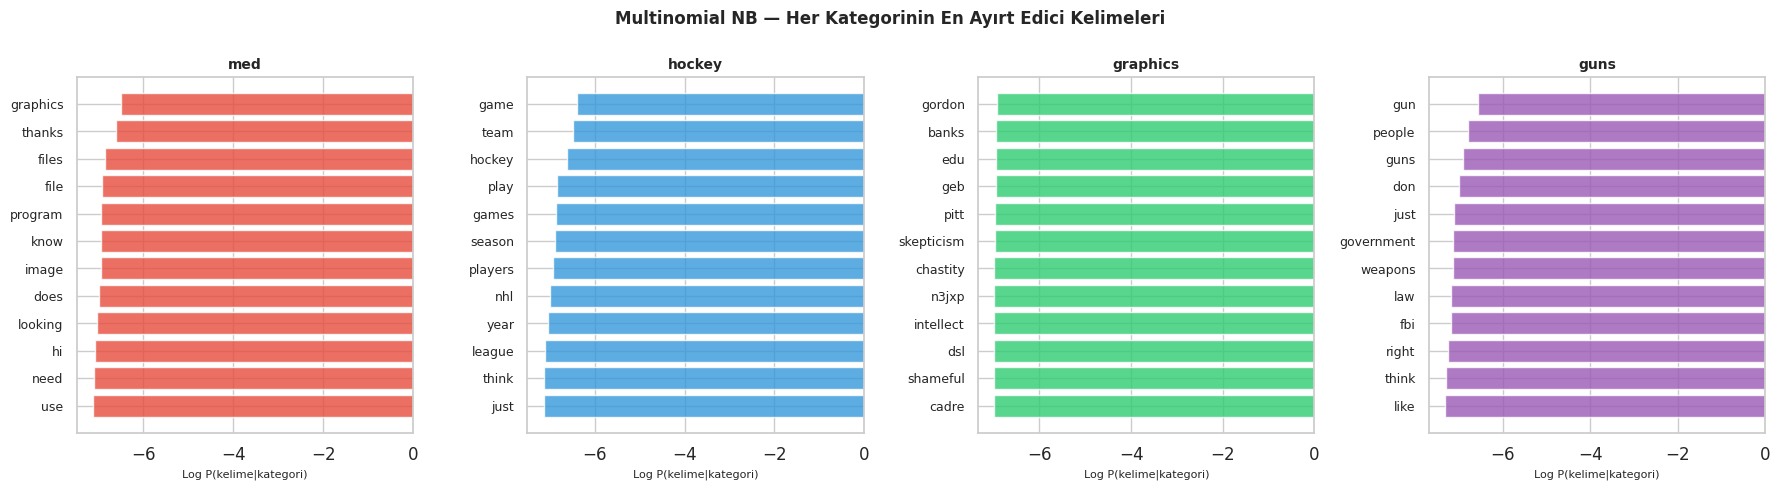

💡 Medikal kategoride: disease, patient, doctor gibi kelimeler dominant.


In [27]:
# ─── Her Kategori İçin En Ayırt Edici Kelimeler ──────────────────────────────
# Log-olasılık farkı en yüksek kelimeler en ayırt edici

feature_names = tfidf.get_feature_names_out()
N_TOP = 12

fig, axes = plt.subplots(1, len(categories), figsize=(18, 5))
fig.suptitle('Multinomial NB — Her Kategorinin En Ayırt Edici Kelimeleri',
             fontsize=12, fontweight='bold')

colors_cat = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

for ax, cat_idx, cat_name, color in zip(axes, range(len(categories)),
                                         categories, colors_cat):
    # Log-olasılık vektörü (bu sınıfa ait belgede kelime frekansları)
    log_probs = mnb.feature_log_prob_[cat_idx]

    # En yüksek log-olasılıklı kelimeler
    top_indices = log_probs.argsort()[-N_TOP:][::-1]
    top_words   = [feature_names[i] for i in top_indices]
    top_scores  = log_probs[top_indices]

    ax.barh(range(N_TOP), top_scores, color=color, alpha=0.8)
    ax.set_yticks(range(N_TOP))
    ax.set_yticklabels(top_words, fontsize=9)
    ax.set_title(cat_name.split('.')[-1], fontsize=10, fontweight='bold')
    ax.set_xlabel('Log P(kelime|kategori)', fontsize=8)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()
print('💡 Medikal kategoride: disease, patient, doctor gibi kelimeler dominant.')

---
## 18. ⚖️ Model Değerlendirme & Karşılaştırma

KNN, Lojistik Regresyon, Karar Ağacı ve Naive Bayes'i aynı veri setleri üzerinde karşılaştırıyoruz.

In [28]:
# ─── Wine Verisi: Tüm Modeller 5-Fold CV Karşılaştırması ─────────────────────

# Ölçeklenmiş versiyon (KNN ve LR için)
scaler_cmp = StandardScaler()
X_wn_tr_sc = scaler_cmp.fit_transform(X_wn_tr)
X_wn_te_sc = scaler_cmp.transform(X_wn_te)

models_cmp = {
    'Karar Ağacı (depth=5)': DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    'Karar Ağacı (depth=3)': DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    'Naive Bayes (Gaussian)': GaussianNB(),
    'KNN (K=7)'             : KNeighborsClassifier(n_neighbors=7),
    'Lojistik Reg (L2)'     : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}

cv_results_cmp = {}

for name, model in models_cmp.items():
    # KNN ve LR ölçeklenmiş versiyon kullanır
    if 'KNN' in name or 'Lojistik' in name:
        X_cv = X_wn_tr_sc
    else:
        X_cv = X_wn_tr

    scores = cross_val_score(
        model, X_cv, y_wn_tr,
        cv=5, scoring='f1_macro', n_jobs=-1
    )
    cv_results_cmp[name] = scores

print('Wine Verisi — 5-Fold CV F1-Macro (Ortalama ± Std):')
for name, scores in cv_results_cmp.items():
    print(f'  {name:35s}: {scores.mean():.4f} ± {scores.std():.4f}')

Wine Verisi — 5-Fold CV F1-Macro (Ortalama ± Std):
  Karar Ağacı (depth=5)              : 0.8989 ± 0.0744
  Karar Ağacı (depth=3)              : 0.9055 ± 0.0813
  Naive Bayes (Gaussian)             : 0.9562 ± 0.0422
  KNN (K=7)                          : 0.9642 ± 0.0230
  Lojistik Reg (L2)                  : 0.9783 ± 0.0177


In [29]:
# ─── Altair: Model Karşılaştırma Boxplot ─────────────────────────────────────

records = []
for m_name, scores in cv_results_cmp.items():
    for fold_i, score in enumerate(scores):
        records.append({'Model': m_name, 'F1 Macro': score, 'Fold': fold_i+1})

df_cmp = pd.DataFrame(records)

chart_cmp = alt.Chart(df_cmp).mark_boxplot(extent='min-max', size=25).encode(
    x=alt.X('F1 Macro:Q',
             scale=alt.Scale(domain=[0.6, 1.02]),
             title='F1-Macro Skoru (5-Fold CV)'),
    y=alt.Y('Model:N', sort='-x', title=''),
    color=alt.Color('Model:N', legend=None)
).properties(
    width=520, height=240,
    title='Wine Verisi — Model Karşılaştırması (5-Fold CV)'
)

chart_cmp.configure_title(fontSize=12).show()

alt.Chart(...)

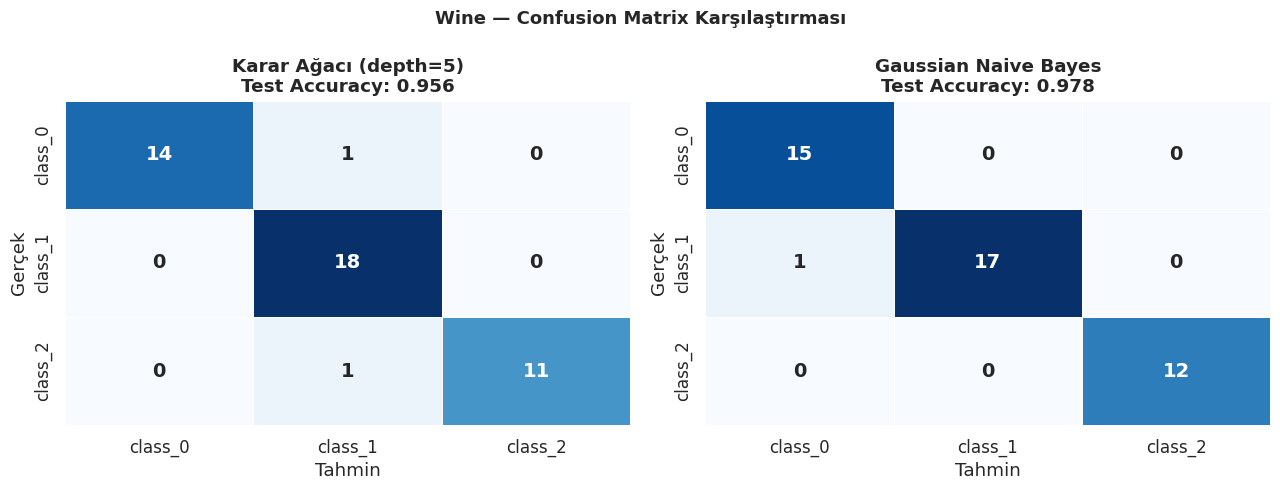

In [30]:
# ─── Confusion Matrix: Karar Ağacı vs Naive Bayes — Wine ─────────────────────

# Modelleri eğit
dt_final = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt_final.fit(X_wn_tr, y_wn_tr)
y_dt_te_pred = dt_final.predict(X_wn_te)

gnb_wine = GaussianNB()
gnb_wine.fit(X_wn_tr, y_wn_tr)
y_gnb_te_pred = gnb_wine.predict(X_wn_te)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Wine — Confusion Matrix Karşılaştırması',
             fontsize=13, fontweight='bold')

for ax, preds, title in [
    (axes[0], y_dt_te_pred,  'Karar Ağacı (depth=5)'),
    (axes[1], y_gnb_te_pred, 'Gaussian Naive Bayes')
]:
    cm = confusion_matrix(y_wn_te, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=wine.target_names,
        yticklabels=wine.target_names,
        linewidths=0.5, ax=ax, cbar=False,
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    acc = accuracy_score(y_wn_te, preds)
    ax.set_title(f'{title}\nTest Accuracy: {acc:.3f}', fontweight='bold')
    ax.set_xlabel('Tahmin')
    ax.set_ylabel('Gerçek')

plt.tight_layout()
plt.show()

In [31]:
# ─── Kapsamlı Model Karşılaştırma Tablosu ─────────────────────────────────────

summary = []

# Tüm modeller — test seti
for name, model in models_cmp.items():
    if 'KNN' in name or 'Lojistik' in name:
        model.fit(X_wn_tr_sc, y_wn_tr)
        preds = model.predict(X_wn_te_sc)
    else:
        model.fit(X_wn_tr, y_wn_tr)
        preds = model.predict(X_wn_te)

    acc = accuracy_score(y_wn_te, preds)
    f1  = f1_score(y_wn_te, preds, average='macro')
    summary.append({'Model': name, 'Test Accuracy': acc, 'F1-Macro': f1})

df_summary = pd.DataFrame(summary).sort_values('F1-Macro', ascending=False)
print('Wine Verisi — Test Seti Sonuçları:')
print(df_summary.to_string(index=False))

Wine Verisi — Test Seti Sonuçları:
                 Model  Test Accuracy  F1-Macro
     Lojistik Reg (L2)       1.000000  1.000000
Naive Bayes (Gaussian)       0.977778  0.979724
             KNN (K=7)       0.977778  0.977143
 Karar Ağacı (depth=5)       0.955556  0.956469
 Karar Ağacı (depth=3)       0.955556  0.956469


---
## 19. 📝 Özet ve Sonraki Adımlar

### Karar Ağaçları

| Konu | Ana Çıkarım |
|------|-------------|
| Temel Fikir | Her adımda veriyi en saf alt gruplara bölen özelliği seç |
| Gini / Entropy | Saflık ölçütleri — Gini daha hızlı, Entropy bilgi teorisi tutarlı |
| CART | İkili bölme, Gini azalma maksimizasyonu |
| max_depth | En kritik hiperparametre — CV ile seç |
| Overfitting | Derinlik artınca eğitim=%100, test düşer |
| Özellik Önemi | Gini azalmasının ağırlıklı toplamı |
| Karar Sınırı | Dikdörtgen yapı — yatay/dikey çizgiler |
| Ölçeklendirme | **Gerekmez** |

### Naive Bayes

| Konu | Ana Çıkarım |
|------|-------------|
| Temel Fikir | Bayes teoremi + koşullu bağımsızlık varsayımı |
| Gaussian NB | Sürekli veri, tıbbi tanı, sensör |
| Multinomial NB | Kelime sayımları, metin sınıflandırma |
| Laplace Smoothing | α parametresi — sıfır olasılık sorununu önler |
| Avantaj | Çok hızlı, az veriyle iyi çalışır, yorumlanabilir |
| Dezavantaj | Bağımsızlık varsayımı gerçekçi değil |

---

### 🚀 Sonraki Hafta: SVM (Destek Vektör Makineleri)

| | Karar Ağacı | Naive Bayes | **SVM** |
||------------|-------------|----------|
| Karar Sınırı | Dikdörtgen | Doğrusal | **Maksimum Marjin** |
| Kernel | Yok | Yok | **RBF, Poly, Sigmoid** |
| Ölçeklendirme | Gerekmez | Gerekmez | **Zorunlu** |
| Büyük Veri | Orta | Hızlı | Yavaş |

### 📚 Ek Kaynaklar:
- **Kitap:** Géron — Hands-On ML, Bölüm 6 (Karar Ağaçları)
- **Kitap:** Mitchell — Machine Learning, Bölüm 3 (ID3)
- **Sklearn DT:** https://scikit-learn.org/stable/modules/tree.html
- **Sklearn NB:** https://scikit-learn.org/stable/modules/naive_bayes.html

In [32]:
# ─── DERS SONU: Tüm Sonuçların Özeti ─────────────────────────────────────────

print('=' * 60)
print(' KARAR AĞACI & NAIVE BAYES — DERS ÖZET')
print('=' * 60)
print()
print('🌳 Karar Ağacı — Iris (150 örnek, 4 özellik):')
print(f'   Sıfırdan (max_depth=3)    : {acc_scratch:.4f}')
print(f'   Sklearn (max_depth=4)     : {acc_dt:.4f}')
print(f'   En iyi CV derinliği       : {best_depth}')
print()
print('🌳 Karar Ağacı — Wine (178 örnek, 13 özellik):')
print(f'   max_depth=5, criterion=entropy : {dt_wine.score(X_wn_te, y_wn_te):.4f}')
print()
print('📊 Gaussian NB — Iris:')
print(f'   Test Doğruluğu: {acc_gnb:.4f}')
print()
print('📝 Multinomial NB — 20 Newsgroups (4 kategori):')
print(f'   Test Doğruluğu: {acc_mnb:.4f}')
print()
print('=' * 60)
print(' Sonraki Ders: SVM (Destek Vektör Makineleri)')
print('=' * 60)

 KARAR AĞACI & NAIVE BAYES — DERS ÖZET

🌳 Karar Ağacı — Iris (150 örnek, 4 özellik):
   Sıfırdan (max_depth=3)    : 0.9211
   Sklearn (max_depth=4)     : 0.9211
   En iyi CV derinliği       : 3

🌳 Karar Ağacı — Wine (178 örnek, 13 özellik):
   max_depth=5, criterion=entropy : 0.9111

📊 Gaussian NB — Iris:
   Test Doğruluğu: 0.9211

📝 Multinomial NB — 20 Newsgroups (4 kategori):
   Test Doğruluğu: 0.9063

 Sonraki Ders: SVM (Destek Vektör Makineleri)
